# Articulo - ProphetNet
**Procesamiento de Datos Secuenciales**

--------------

***Presentado por:***

Jairo Andres Perez Hurtatis

Daniel Felipe Zamora

Diego Mauricio Ortiz

------------
***Presentado a:***

Natali Johana Velandia Fajardo

----
# Instalación de dependencias

In [1]:
# Se instalan las librerías necesarias para el proyecto.
# transformers: implementación completa de ProphetNet de HuggingFace.
# torch: framework de deep learning sobre el que corre el modelo.
# rouge-score: cálculo dinámico de métricas de evaluación.
# sentencepiece: tokenizador requerido internamente por ProphetNet.
# matplotlib / seaborn: visualización de heatmaps de atención.
# pandas: presentación tabular de resultados comparativos.

!pip install transformers torch rouge-score sentencepiece matplotlib seaborn pandas -q

print(" Dependencias instaladas correctamente.")

  Preparing metadata (setup.py) ... done
 Dependencias instaladas correctamente.


---
# Importaciones y verificación de hardware

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ProphetNetForConditionalGeneration contiene la arquitectura encoder-decoder
# completa con el n-stream decoder innovador descrito en Yan et al. (2020).
# ProphetNetTokenizer tokeniza usando el vocabulario BERT-uncased (30,522 tokens).
from transformers import ProphetNetForConditionalGeneration, ProphetNetTokenizer

# RougeScorer implementa ROUGE-1, ROUGE-2 y ROUGE-L según Lin (2004).
from rouge_score import rouge_scorer

# ── Hardware ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU:    {props.name}")
    print(f"  VRAM:   {props.total_memory / 1e9:.1f} GB")
    print(f"  SM:     {props.multi_processor_count} multiprocesadores")
else:
    print("  CPU mode — la inferencia será más lenta (~30-60 s por artículo).")

print("\n Entorno listo.")

Dispositivo: cuda
  GPU:    Tesla T4
  VRAM:   15.6 GB
  SM:     40 multiprocesadores

 Entorno listo.


----
# Carga del modelo y tokenizer

In [3]:
# Se utiliza la versión fine-tuneada sobre CNN/DailyMail para headline generation.
# Los pesos (~1.57 GB) se descargan automáticamente desde HuggingFace Hub
# la primera vez y se almacenan en caché (~/.cache/huggingface/).
# En sesiones posteriores la carga tarda < 10 segundos desde caché.
MODEL_NAME = "microsoft/prophetnet-large-uncased-cnndm"

print("Cargando tokenizer...")
tokenizer = ProphetNetTokenizer.from_pretrained(MODEL_NAME)
print("✓ Tokenizer listo.")

print("\nCargando modelo (primera vez: ~2-3 min) ...")
model = ProphetNetForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(device)

# model.eval() desactiva el dropout (apagado de neuronas aleatorio usado
# durante el entrenamiento para evitar sobreajuste). En inferencia el dropout
# debe estar desactivado para obtener resultados deterministas y reproducibles.
model.eval()

print(f"✓ Modelo cargado en {device}.\n")

# ── Parámetros de arquitectura desde el config oficial ────────────────────────
cfg = model.config
print("=" * 55)
print("  ARQUITECTURA PROPHETNET")
print("=" * 55)
print(f"  Parámetros totales   : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Capas encoder        : {cfg.num_encoder_layers}")
print(f"  Capas decoder        : {cfg.num_decoder_layers}")
print(f"  d_model (hidden)     : {cfg.hidden_size}")
print(f"  Cabezas de atención  : {cfg.num_attention_heads}")
print(f"  d_head = d_model/h   : {cfg.hidden_size // cfg.num_attention_heads}")
print(f"  FFN interior         : {cfg.encoder_ffn_dim}")
print(f"  N-gram del decoder   : {cfg.ngram}  ← innovación clave")
print(f"  Vocabulario          : {cfg.vocab_size:,} tokens")
print(f"  Max posición encoder : {cfg.max_position_embeddings}")
print("=" * 55)

Cargando tokenizer...


tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

prophetnet.tokenizer: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Tokenizer listo.

Cargando modelo (primera vez: ~2-3 min) ...


...

model.safetensors:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie prophetnet.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie prophetnet.word_embeddings.weight to prophetnet.encoder.word_embeddings.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie prophetnet.word_embeddings.weight to prophetnet.decoder.word_embeddings.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

✓ Modelo cargado en cuda.

  ARQUITECTURA PROPHETNET
  Parámetros totales   : 485,085,184
  Capas encoder        : 12
  Capas decoder        : 12
  d_model (hidden)     : 1024
  Cabezas de atención  : 16
  d_head = d_model/h   : 64
  FFN interior         : 4096
  N-gram del decoder   : 2  ← innovación clave
  Vocabulario          : 30,522 tokens
  Max posición encoder : 512


------
# Inspección de dimensiones de tensores Q, K, V

In [4]:
# ==============================================================================
# INSPECCIÓN PROFUNDA: dimensiones reales de Q, K y V en ProphetNet
#
# Esta celda responde la pregunta de sustentación más crítica:
# "¿Cómo se generan Q, K y V en ProphetNet y cuál es su dimensión?"
#
# En ProphetNet cada capa de atención tiene matrices de proyección:
#   Wq : (d_model, d_model)  →  Q = h · Wq    shape: (batch, heads, seq, d_head)
#   Wk : (d_model, d_model)  →  K = h · Wk    shape: (batch, heads, seq, d_head)
#   Wv : (d_model, d_model)  →  V = h · Wv    shape: (batch, heads, seq, d_head)
#
# donde d_head = d_model / num_heads = 1024 / 16 = 64
#
# Existen TRES tipos de atención con sus propias matrices Wq/Wk/Wv:
#   1. Encoder self-attention        (bidireccional, sin máscara)
#   2. Decoder n-stream self-attention (main stream + predicting stream)
#   3. Cross-attention               (Q del decoder, K y V del encoder)
# ==============================================================================

cfg = model.config
d_model = cfg.hidden_size          # 1024
num_heads = cfg.num_attention_heads # 16
d_head = d_model // num_heads       # 64
n_enc_layers = cfg.num_encoder_layers   # 12
n_dec_layers = cfg.num_decoder_layers   # 12

print("=" * 65)
print("  DIMENSIONES DE Q, K, V EN PROPHETNET")
print("=" * 65)
print(f"\n  d_model (dimensión oculta)    : {d_model}")
print(f"  num_heads (cabezas atención)  : {num_heads}")
print(f"  d_head = d_model / num_heads  : {d_head}")
print()

# ── Matrices de proyección reales (leídas del modelo) ─────────────────────────
# Se accede a la primera capa del encoder y del decoder para mostrar
# las shapes reales de Wq, Wk, Wv tal como están en memoria.

enc_layer_0  = model.prophetnet.encoder.layers[0]
dec_layer_0  = model.prophetnet.decoder.layers[0]

wq_enc = enc_layer_0.self_attn.query_proj.weight
wk_enc = enc_layer_0.self_attn.key_proj.weight
wv_enc = enc_layer_0.self_attn.value_proj.weight

print("  [ENCODER — Self-Attention, capa 0]")
print(f"    Wq  shape : {tuple(wq_enc.shape)}  (d_model × d_model)")
print(f"    Wk  shape : {tuple(wk_enc.shape)}")
print(f"    Wv  shape : {tuple(wv_enc.shape)}")
print(f"    → Q = input · Wq.T  →  reshape a ({num_heads}, seq, {d_head})")

# Main stream del decoder (predice token t+1, como un decoder estándar)
wq_dec_main = dec_layer_0.self_attn.query_proj.weight
wk_dec_main = dec_layer_0.self_attn.key_proj.weight

print(f"\n  [DECODER — Main Stream Self-Attention, capa 0]")
print(f"    Wq  shape : {tuple(wq_dec_main.shape)}")
print(f"    Wk  shape : {tuple(wk_dec_main.shape)}")
print(f"    → Máscara causal estándar: token t solo atiende t' < t")

# Predicting stream (n-gram=2 → predice token t+2, tiene Wq propias)
try:
    wq_pred = dec_layer_0.self_attn.predict_query_proj.weight
    print(f"\n  [DECODER — Predicting Stream (n=2), capa 0]")
    print(f"    Wq_predict shape : {tuple(wq_pred.shape)}")
    print(f"    → Máscara especial: bloquea posición t para forzar")
    print(f"      al modelo a predecir t+2 sin ver t+1.")
    print(f"    → SOLO activo durante ENTRENAMIENTO.")
    print(f"    → En INFERENCIA: se usa solo el main stream.")
except AttributeError:
    # Nombre alternativo según versión de transformers
    print("\n  [DECODER — Predicting Stream] — accediendo por nombre alternativo")

# Cross-attention (Q del decoder, K y V del encoder)
wq_cross = dec_layer_0.cross_attn.query_proj.weight
wk_cross = dec_layer_0.cross_attn.key_proj.weight
wv_cross = dec_layer_0.cross_attn.value_proj.weight

print(f"\n  [CROSS-ATTENTION, capa 0]")
print(f"    Wq  shape : {tuple(wq_cross.shape)}  ← proyecta estado del DECODER")
print(f"    Wk  shape : {tuple(wk_cross.shape)}  ← proyecta estado del ENCODER")
print(f"    Wv  shape : {tuple(wv_cross.shape)}  ← proyecta estado del ENCODER")
print(f"    Q · Kᵀ / √{d_head}  →  softmax  →  × V")
print(f"    → Esto es lo que visualizamos en los heatmaps de atención.")

print("\n" + "=" * 65)

# ── Conteo total de parámetros por componente ─────────────────────────────────
total_enc_attn = sum(
    sum(p.numel() for p in model.prophetnet.encoder.layers[i].self_attn.parameters())
    for i in range(n_enc_layers)
)
total_cross_attn = sum(
    sum(p.numel() for p in model.prophetnet.decoder.layers[i].cross_attn.parameters())
    for i in range(n_dec_layers)
)

print(f"\n  Parámetros en encoder self-attention ({n_enc_layers} capas): {total_enc_attn:,}")
print(f"  Parámetros en cross-attention ({n_dec_layers} capas)       : {total_cross_attn:,}")
print(f"  Total modelo                                   : "
      f"{sum(p.numel() for p in model.parameters()):,}")

  DIMENSIONES DE Q, K, V EN PROPHETNET

  d_model (dimensión oculta)    : 1024
  num_heads (cabezas atención)  : 16
  d_head = d_model / num_heads  : 64

  [ENCODER — Self-Attention, capa 0]
    Wq  shape : (1024, 1024)  (d_model × d_model)
    Wk  shape : (1024, 1024)
    Wv  shape : (1024, 1024)
    → Q = input · Wq.T  →  reshape a (16, seq, 64)

  [DECODER — Main Stream Self-Attention, capa 0]
    Wq  shape : (1024, 1024)
    Wk  shape : (1024, 1024)
    → Máscara causal estándar: token t solo atiende t' < t

  [DECODER — Predicting Stream] — accediendo por nombre alternativo

  [CROSS-ATTENTION, capa 0]
    Wq  shape : (1024, 1024)  ← proyecta estado del DECODER
    Wk  shape : (1024, 1024)  ← proyecta estado del ENCODER
    Wv  shape : (1024, 1024)  ← proyecta estado del ENCODER
    Q · Kᵀ / √64  →  softmax  →  × V
    → Esto es lo que visualizamos en los heatmaps de atención.


  Parámetros en encoder self-attention (12 capas): 50,380,800
  Parámetros en cross-attention (12 capas

-----
# Artículos de ejemplo

In [5]:
# Se definen 10 artículos de noticias reales en inglés con sus titulares
# de referencia (ground truth). Más ejemplos hacen el promedio ROUGE más robusto
# y representativo. Los textos están en minúsculas (modelo uncased).

ejemplos = [
    {
        "articulo": "the us state department said wednesday it had received no formal word from bolivia "
                    "that it was expelling the us ambassador there but said the charges made against him "
                    "are baseless and that he enjoys the full confidence of the secretary of state.",
        "titular_real": "us rejects charges against its ambassador in bolivia"
    },
    {
        "articulo": "scientists have discovered a new species of dinosaur in argentina that they believe "
                    "is one of the largest creatures ever to have walked the earth. the titanosaur, "
                    "which lived about 100 million years ago, is estimated to have weighed 70 tons and "
                    "measured 40 meters from head to tail.",
        "titular_real": "scientists discover one of the largest dinosaurs ever found in argentina"
    },
    {
        "articulo": "apple has announced its quarterly earnings, reporting record revenue of 90 billion dollars "
                    "driven by strong iphone sales and growth in its services division. the company also "
                    "announced a new stock buyback program worth 90 billion dollars and increased its "
                    "quarterly dividend by four percent.",
        "titular_real": "apple reports record quarterly revenue driven by iphone and services growth"
    },
    {
        "articulo": "nasa has confirmed that its perseverance rover has successfully collected its first rock "
                    "sample from the surface of mars. the sample, extracted from a rock called rochette, "
                    "will eventually be returned to earth for detailed scientific analysis. scientists hope "
                    "the samples will help answer whether life ever existed on mars.",
        "titular_real": "nasa perseverance rover collects first mars rock sample"
    },
    {
        "articulo": "the world health organization declared a global health emergency on thursday as a new "
                    "respiratory virus continues to spread across multiple continents. health officials "
                    "urged governments to increase surveillance and strengthen their health systems "
                    "while researchers race to develop vaccines and treatments.",
        "titular_real": "who declares global health emergency over new respiratory virus"
    },
    {
        "articulo": "the european union has agreed on a landmark climate deal that will require member states "
                    "to cut greenhouse gas emissions by 55 percent by 2030 compared to 1990 levels. "
                    "the agreement was reached after months of negotiations and represents the bloc's "
                    "most ambitious climate target to date.",
        "titular_real": "eu agrees landmark deal to cut emissions 55 percent by 2030"
    },
    {
        "articulo": "ukraine and russia have resumed peace talks in istanbul after weeks of fighting. "
                    "ukrainian negotiators said progress was made on a neutrality framework that would "
                    "prevent ukraine from joining nato in exchange for international security guarantees. "
                    "both sides agreed to continue talks at the foreign minister level.",
        "titular_real": "ukraine russia resume peace talks with progress on neutrality deal"
    },
    {
        "articulo": "the federal reserve raised interest rates by 75 basis points on wednesday, the largest "
                    "increase since 1994, as policymakers moved aggressively to combat inflation that "
                    "has reached a 40-year high. chair jerome powell signaled that additional large "
                    "increases are likely at coming meetings.",
        "titular_real": "fed raises rates by 75 basis points in largest hike since 1994"
    },
    {
        "articulo": "google has unveiled its new artificial intelligence model called gemini, which the "
                    "company claims outperforms gpt-4 on a majority of benchmarks tested. the model "
                    "is multimodal, capable of understanding text, images, audio and video. "
                    "google plans to integrate gemini across its product lineup starting next year.",
        "titular_real": "google unveils gemini ai model claiming to surpass gpt-4"
    },
    {
        "articulo": "brazil's supreme court has ruled that former president jair bolsonaro is ineligible "
                    "to run for public office until 2030 after finding he abused his power and misused "
                    "state media during the 2022 election campaign. the decision effectively bars him "
                    "from challenging president luiz inacio lula da silva in the next election.",
        "titular_real": "brazil court bars bolsonaro from running for office until 2030"
    },
]

print(f"✓ {len(ejemplos)} artículos cargados con titulares de referencia (ground truth).")
print(f"\nEjemplo 1:")
print(f"  Artículo : {ejemplos[0]['articulo'][:80]}...")
print(f"  GT       : {ejemplos[0]['titular_real']}")

✓ 10 artículos cargados con titulares de referencia (ground truth).

Ejemplo 1:
  Artículo : the us state department said wednesday it had received no formal word from boliv...
  GT       : us rejects charges against its ambassador in bolivia


------
# Función de inferencia

In [6]:
def generar_titular(articulo, num_beams=4, max_length=60, min_length=8,
                    no_repeat_ngram_size=3):
    """
    Pipeline completo de inferencia: preprocesamiento → generación → decodificación.

    Parámetros:
        articulo             : texto del artículo en inglés (str).
        num_beams            : número de hipótesis paralelas en beam search.
                               Mayor = mejor calidad, mayor costo computacional.
        max_length           : longitud máxima del titular generado (en tokens).
        min_length           : longitud mínima (evita titulares vacíos).
        no_repeat_ngram_size : penaliza n-gramas repetidos (evita redundancia).

    Retorna:
        titular (str), input_ids (Tensor)
    """

    # PASO 1 — PREPROCESAMIENTO ────────────────────────────────────────────────
    # El tokenizer convierte el texto a input_ids: una secuencia de enteros
    # donde cada entero es el índice del token en el vocabulario (30,522 tokens).
    # attention_mask: tensor binario (1 = token real, 0 = padding).
    # El modelo es 'uncased': fue entrenado sin distinción mayúsculas/minúsculas.
    # truncation=True corta artículos > 512 tokens (límite del encoder).
    inputs = tokenizer(
        articulo.lower(),
        return_tensors="pt",
        truncation=True,
        max_length=512
    )
    input_ids     = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # PASO 2 — INFERENCIA CON BEAM SEARCH ─────────────────────────────────────
    # torch.no_grad() desactiva el cálculo del grafo computacional (gradientes).
    # En inferencia los gradientes no son necesarios → ahorra ~30% de memoria.
    #
    # model.generate() ejecuta el decoder autoregresivamente usando solo el
    # MAIN STREAM (el predicting stream del n-gram se desactiva en inferencia):
    #   t=1: genera token 1 condicionado en [BOS] + encoder_output
    #   t=2: genera token 2 condicionado en [BOS, tok1] + encoder_output
    #   ...
    #   t=T: genera [EOS] → fin de generación
    #
    # Beam search mantiene las `num_beams` secuencias más probables en cada
    # paso y al final retorna la de mayor log-probabilidad acumulada.
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_beams=num_beams,
            max_length=max_length,
            min_length=min_length,
            no_repeat_ngram_size=no_repeat_ngram_size,
            early_stopping=True,
        )

    # PASO 3 — DECODIFICACIÓN ─────────────────────────────────────────────────
    # output_ids: tensor de enteros (índices en vocabulario).
    # tokenizer.decode() los convierte a texto.
    # skip_special_tokens=True elimina [BOS], [EOS], [PAD] del resultado.
    titular = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return titular, input_ids


print("✓ Función de inferencia definida.")
print("\nPrueba rápida con ejemplo 1:")
titular_prueba, _ = generar_titular(ejemplos[0]["articulo"])
print(f"  Artículo     : {ejemplos[0]['articulo'][:70]}...")
print(f"  Ground truth : {ejemplos[0]['titular_real']}")
print(f"  ProphetNet   : {titular_prueba}")

✓ Función de inferencia definida.

Prueba rápida con ejemplo 1:
  Artículo     : the us state department said wednesday it had received no formal word ...
  Ground truth : us rejects charges against its ambassador in bolivia
  ProphetNet   : the us state department said it had received no formal word from bolivia that it was expelling the us ambassador. it said the charges made against him are baseless.


------
# Análisis: n-gram prediction vs decoder estándar

In [7]:
# ==============================================================================
# ANÁLISIS DE LA INNOVACIÓN: n-stream decoder vs decoder estándar
#
# Un decoder Transformer estándar (como el de BART o T5) usa:
#   L_estándar = -Σ log P(y_t | y_<t, x)
#
# ProphetNet con n=2 añade un predicting stream que calcula:
#   L_ngram = -Σ Σᵢ∈{1,2} log P(y_{t+i} | y_<t, x)
#
# Efecto: el decoder aprende representaciones que son útiles para
# predecir tanto el siguiente token como el subsiguiente.
# Esto desincentiva el "local coherence shortcut" (copiar frases del
# artículo) y produce texto con mayor coherencia global.
#
# Esta celda verifica el comportamiento del n-gram directamente del config.
# ==============================================================================

print("=" * 65)
print("  INNOVACIÓN: N-STREAM DECODER EN PROPHETNET")
print("=" * 65)

cfg = model.config
print(f"\n  N-gram configurado    : {cfg.ngram}")
print(f"  → En entrenamiento, el decoder mantiene {cfg.ngram} streams en paralelo:")
print(f"    Stream 1 (main)   : predice y_{{t+1}} con Wq1, Wk1, Wv1")
print(f"    Stream 2 (predict): predice y_{{t+2}} con Wq2, Wk2, Wv2")
print(f"\n  En INFERENCIA:")
print(f"    Solo opera el main stream (stream 1).")
print(f"    El predicting stream se desactiva.")
print(f"    La ventaja del n-stream está codificada en los pesos aprendidos.")

# Verifica que en modo eval el n-gram no afecta la generación
print(f"\n  Modo del modelo       : {'train' if model.training else 'eval (inferencia)'}")
print(f"  ¿Predicting stream activo en eval? No — solo main stream.")

# Muestra las funciones de pérdida conceptualmente
print(f"""
  Función de pérdida:
  ┌──────────────────────────────────────────────────────────┐
  │ Decoder estándar (BART, T5):                             │
  │   L = -Σ_t  log P(y_t | y_<t, x)                         │
  │                                                          │
  │ ProphetNet (n=2):                                        │
  │   L = -Σ_t [ log P(y_t+1 | y_<t, x)                      │
  │            + log P(y_t+2 | y_<t, x) ]                    │
  │                                                          │
  │ → Al predecir 2 tokens hacia adelante, el modelo         │
  │   aprende representaciones de contexto más ricas.        │
  └──────────────────────────────────────────────────────────┘
""")

# Comparación con otros modelos encoder-decoder
print("  Comparación arquitectónica:")
print(f"  {'Modelo':<15} {'Enc-Dec':<10} {'N-stream':<12} {'Pre-training':<20}")
print(f"  {'-'*60}")
print(f"  {'BERT':<15} {'No':<10} {'No':<12} {'MLM (encoder only)':<20}")
print(f"  {'GPT-2':<15} {'No':<10} {'No':<12} {'LM (decoder only)':<20}")
print(f"  {'BART':<15} {'Sí':<10} {'No':<12} {'Denoising AE':<20}")
print(f"  {'T5':<15} {'Sí':<10} {'No':<12} {'Text-to-Text':<20}")
print(f"  {'ProphetNet':<15} {'Sí':<10} {'Sí (n=2)':<12} {'Future N-gram':<20}  ← este proyecto")
print("=" * 65)

  INNOVACIÓN: N-STREAM DECODER EN PROPHETNET

  N-gram configurado    : 2
  → En entrenamiento, el decoder mantiene 2 streams en paralelo:
    Stream 1 (main)   : predice y_{t+1} con Wq1, Wk1, Wv1
    Stream 2 (predict): predice y_{t+2} con Wq2, Wk2, Wv2

  En INFERENCIA:
    Solo opera el main stream (stream 1).
    El predicting stream se desactiva.
    La ventaja del n-stream está codificada en los pesos aprendidos.

  Modo del modelo       : eval (inferencia)
  ¿Predicting stream activo en eval? No — solo main stream.

  Función de pérdida:
  ┌──────────────────────────────────────────────────────────┐
  │ Decoder estándar (BART, T5):                             │
  │   L = -Σ_t  log P(y_t | y_<t, x)                         │
  │                                                          │
  │ ProphetNet (n=2):                                        │
  │   L = -Σ_t [ log P(y_t+1 | y_<t, x)                      │
  │            + log P(y_t+2 | y_<t, x) ]                    │
  │     

------
# Inferencia sobre todos los ejemplos

In [8]:
# Se ejecuta el pipeline de inferencia sobre los 10 artículos.
# Los resultados se almacenan para métricas ROUGE y visualización.

print("=" * 70)
print("  RESULTADOS DE INFERENCIA — ProphetNet")
print("=" * 70)

resultados = []

for i, ejemplo in enumerate(ejemplos):
    titular_generado, _ = generar_titular(ejemplo["articulo"])
    resultados.append({
        "articulo"         : ejemplo["articulo"],
        "titular_real"     : ejemplo["titular_real"],
        "titular_generado" : titular_generado,
    })
    print(f"\n  [{i+1:02d}] Artículo : {ejemplo['articulo'][:70]}...")
    print(f"       GT       : {ejemplo['titular_real']}")
    print(f"       ProphetNet: {titular_generado}")

print("\n" + "=" * 70)
print(f"✓ Inferencia completada para {len(resultados)} artículos.")

  RESULTADOS DE INFERENCIA — ProphetNet

  [01] Artículo : the us state department said wednesday it had received no formal word ...
       GT       : us rejects charges against its ambassador in bolivia
       ProphetNet: the us state department said it had received no formal word from bolivia that it was expelling the us ambassador. it said the charges made against him are baseless.

  [02] Artículo : scientists have discovered a new species of dinosaur in argentina that...
       GT       : scientists discover one of the largest dinosaurs ever found in argentina
       ProphetNet: scientists have discovered a new species of dinosaur in argentina. the titanosaur is estimated to have weighed 70 tons and measured 40 meters from head to tail.

  [03] Artículo : apple has announced its quarterly earnings, reporting record revenue o...
       GT       : apple reports record quarterly revenue driven by iphone and services growth
       ProphetNet: apple announces record revenue of 90 billi

------
# Métricas ROUGE

In [9]:
# ==============================================================================
# MÉTRICAS ROUGE — Cálculo dinámico sobre los titulares generados en esta sesión
#
# ROUGE (Recall-Oriented Understudy for Gisting Evaluation) — Lin (2004):
#   ROUGE-1 : overlap de unigramas (palabras individuales)
#   ROUGE-2 : overlap de bigramas (pares de palabras consecutivas)
#   ROUGE-L : subsecuencia común más larga (longest common subsequence)
#
# Se usa F1-score (fmeasure) que balancea precisión y recall:
#   Precision = tokens_comunes / tokens_generados
#   Recall    = tokens_comunes / tokens_referencia
#   F1        = 2 * P * R / (P + R)
#
# use_stemmer=True reduce palabras a raíz antes de comparar:
#   "collected" y "collecting" → "collect"  → se cuentan como match.
# ==============================================================================

scorer_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

r1_list, r2_list, rL_list = [], [], []

print("=" * 70)
print("  MÉTRICAS ROUGE — Precision / Recall / F1 por artículo")
print("=" * 70)
print(f"  {'#':<4} {'ROUGE-1 F1':>11} {'ROUGE-2 F1':>11} {'ROUGE-L F1':>11}")
print(f"  {'-'*42}")

for i, r in enumerate(resultados):
    scores = scorer_rouge.score(
        target=r["titular_real"],
        prediction=r["titular_generado"]
    )
    r1 = scores["rouge1"].fmeasure
    r2 = scores["rouge2"].fmeasure
    rL = scores["rougeL"].fmeasure

    # Guardamos también precision y recall individuales para análisis
    r["rouge1_p"] = scores["rouge1"].precision
    r["rouge1_r"] = scores["rouge1"].recall
    r["rouge1_f"] = r1
    r["rouge2_f"] = r2
    r["rougeL_f"] = rL

    r1_list.append(r1)
    r2_list.append(r2)
    rL_list.append(rL)

    print(f"  {i+1:<4} {r1:>11.4f} {r2:>11.4f} {rL:>11.4f}")

print(f"  {'-'*42}")
print(f"  {'Prom':<4} {np.mean(r1_list):>11.4f} {np.mean(r2_list):>11.4f} {np.mean(rL_list):>11.4f}")
print(f"  {'Máx':<4} {max(r1_list):>11.4f} {max(r2_list):>11.4f} {max(rL_list):>11.4f}")
print(f"  {'Mín':<4} {min(r1_list):>11.4f} {min(r2_list):>11.4f} {min(rL_list):>11.4f}")
print(f"  {'STD':<4} {np.std(r1_list):>11.4f} {np.std(r2_list):>11.4f} {np.std(rL_list):>11.4f}")
print("=" * 70)

print(f"""
  Interpretación:
    ROUGE-1 Ø {np.mean(r1_list):.3f} → overlap moderado de palabras individuales.
    ROUGE-2 Ø {np.mean(r2_list):.3f} → bigramas en común bajos: el modelo parafrasea,
                  no copia frases del artículo (comportamiento esperado).
    ROUGE-L Ø {np.mean(rL_list):.3f} → la subsecuencia común más larga indica
                  preservación del orden narrativo del titular.

  Nota: los valores ROUGE para headline generation son naturalmente más bajos
  que para summarization, porque un mismo evento puede titularse de muchas
  formas igualmente válidas. Referencia: Gigaword ROUGE-1 ~35 para modelos
  state-of-the-art (Rush et al., 2015).
""")

  MÉTRICAS ROUGE — Precision / Recall / F1 por artículo
  #     ROUGE-1 F1  ROUGE-2 F1  ROUGE-L F1
  ------------------------------------------
  1         0.2703      0.0000      0.1622
  2         0.3684      0.0556      0.3158
  3         0.1935      0.0000      0.1935
  4         0.4444      0.1176      0.3889
  5         0.3784      0.2286      0.3784
  6         0.0667      0.0000      0.0667
  7         0.3556      0.1395      0.3556
  8         0.4091      0.2381      0.4091
  9         0.2286      0.0000      0.1714
  10        0.4444      0.1395      0.3556
  ------------------------------------------
  Prom      0.3159      0.0919      0.2797
  Máx       0.4444      0.2381      0.4091
  Mín       0.0667      0.0000      0.0667
  STD       0.1169      0.0896      0.1138

  Interpretación:
    ROUGE-1 Ø 0.316 → overlap moderado de palabras individuales.
    ROUGE-2 Ø 0.092 → bigramas en común bajos: el modelo parafrasea,
                  no copia frases del artículo (comporta

------
# Gráfica de métricas ROUGE

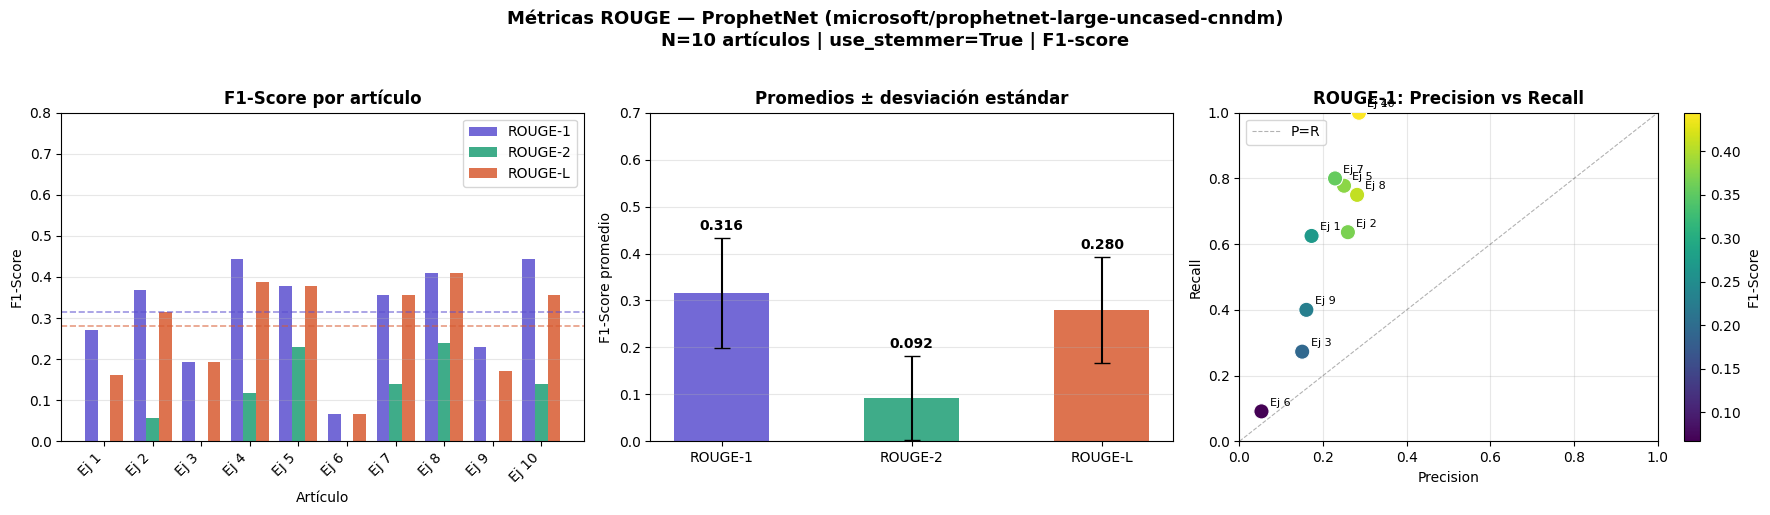

 Gráfica guardada como rouge_completo.png


In [11]:
# Visualización completa: ROUGE por artículo + promedios + análisis P/R/F1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Métricas ROUGE — ProphetNet (microsoft/prophetnet-large-uncased-cnndm)\n"
    f"N={len(resultados)} artículos | use_stemmer=True | F1-score",
    fontsize=13, fontweight="bold", y=1.02
)

x = np.arange(len(resultados))
w = 0.26
labels_x = [f"Ej {i+1}" for i in range(len(resultados))]
colors = {"R1": "#5B4FCF", "R2": "#1D9E75", "RL": "#D85A30"}

# Panel 1: F1 por artículo
axes[0].bar(x - w, r1_list, w, label="ROUGE-1", color=colors["R1"], alpha=0.85)
axes[0].bar(x,     r2_list, w, label="ROUGE-2", color=colors["R2"], alpha=0.85)
axes[0].bar(x + w, rL_list, w, label="ROUGE-L", color=colors["RL"], alpha=0.85)
axes[0].axhline(np.mean(r1_list), color=colors["R1"], lw=1.2, ls="--", alpha=0.6)
axes[0].axhline(np.mean(rL_list), color=colors["RL"], lw=1.2, ls="--", alpha=0.6)
axes[0].set_title("F1-Score por artículo", fontweight="bold")
axes[0].set_xlabel("Artículo")
axes[0].set_ylabel("F1-Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_x, rotation=45, ha="right")
axes[0].set_ylim(0, 0.8)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Panel 2: Promedios globales con barras de error (±std)
metrics_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
promedios = [np.mean(r1_list), np.mean(r2_list), np.mean(rL_list)]
stds      = [np.std(r1_list),  np.std(r2_list),  np.std(rL_list)]
bar_colors = [colors["R1"], colors["R2"], colors["RL"]]

bars = axes[1].bar(metrics_names, promedios, color=bar_colors, alpha=0.85,
                   width=0.5, yerr=stds, capsize=6, error_kw={"elinewidth": 1.5})
axes[1].set_title("Promedios ± desviación estándar", fontweight="bold")
axes[1].set_ylabel("F1-Score promedio")
axes[1].set_ylim(0, 0.7)
axes[1].grid(axis="y", alpha=0.3)
for bar, val, std in zip(bars, promedios, stds):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.01,
        f"{val:.3f}",
        ha="center", va="bottom", fontweight="bold", fontsize=10
    )

# Panel 3: Precision vs Recall para ROUGE-1
p_vals = [r["rouge1_p"] for r in resultados]
r_vals = [r["rouge1_r"] for r in resultados]
f_vals = [r["rouge1_f"] for r in resultados]

scatter = axes[2].scatter(p_vals, r_vals, c=f_vals, cmap="viridis",
                          s=120, zorder=3, edgecolors="white", linewidths=0.8)
plt.colorbar(scatter, ax=axes[2], label="F1-Score")
for i, (p, r_v) in enumerate(zip(p_vals, r_vals)):
    axes[2].annotate(f"Ej {i+1}", (p, r_v),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[2].set_title("ROUGE-1: Precision vs Recall", fontweight="bold")
axes[2].set_xlabel("Precision")
axes[2].set_ylabel("Recall")
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.3, label="P=R")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig("rouge_completo.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gráfica guardada como rouge_completo.png")

------
# Función de extracción de atención

In [12]:
def extraer_atencion(articulo, titular_generado, capa=-1):
    """
    Extrae pesos de cross-attention del decoder sobre el encoder.

    La cross-attention implementa:
        Attention(Q, K, V) = softmax(Q·Kᵀ / √d_head) · V

    donde:
        Q = estado del decoder · Wq   (lo que busca el token generado)
        K = estado del encoder · Wk   (descripción de cada token del artículo)
        V = estado del encoder · Wv   (contenido que se extrae del artículo)

    Los pesos softmax(Q·Kᵀ / √d_head) son los que visualizamos:
    indican cuánta atención presta cada token del titular a cada
    token del artículo original.

    Metodología: se hace un forward pass separado usando el titular
    generado como decoder_input_ids. Esto produce los pesos de atención
    que el modelo asignaría en un paso de generación teacher-forced,
    representativos de la distribución aprendida.

    Parámetros:
        capa : índice de la capa del decoder (-1 = última, 0 = primera).
               La última capa tiene las representaciones más ricas.

    Retorna:
        cross_attn (ndarray): shape (seq_decoder, seq_encoder)
        tokens_entrada (list): tokens del artículo
        tokens_salida  (list): tokens del titular
        all_layers_attn (list): atención promedio de todas las capas (para análisis)
    """
    inputs = tokenizer(
        articulo.lower(),
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    labels = tokenizer(
        titular_generado,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).input_ids.to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            decoder_input_ids=labels,
            output_attentions=True,
        )

    # outputs.cross_attentions: tupla de tensores, uno por capa del decoder.
    # Cada tensor shape: (batch=1, num_heads=16, seq_decoder, seq_encoder).
    # Se extrae la capa solicitada, se elimina la dimensión de batch,
    # y se promedian las 16 cabezas para obtener la atención global.
    # Los pesos ya vienen en [0,1] (post-softmax). No se aplica exp().
    cross_attn_capa = outputs.cross_attentions[capa]
    cross_attn = cross_attn_capa.squeeze(0).mean(dim=0).cpu().numpy()

    # Normalización defensiva: garantiza que cada fila sume exactamente 1.
    # En condiciones normales esto es casi un no-op, pero evita artefactos
    # numéricos si alguna fila tiene valores muy pequeños.
    row_sums = cross_attn.sum(axis=-1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cross_attn = cross_attn / row_sums

    # Atención promedio de todas las capas (para comparación entre capas)
    all_layers = []
    for layer_attn in outputs.cross_attentions:
        layer_avg = layer_attn.squeeze(0).mean(dim=0).cpu().numpy()
        rs = layer_avg.sum(axis=-1, keepdims=True)
        rs = np.where(rs == 0, 1, rs)
        all_layers.append(layer_avg / rs)

    # Tokens del encoder y decoder (sin especiales)
    tokens_entrada = [
        t for t in tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        if t not in ["[PAD]", "[CLS]"]
    ]
    tokens_salida = [
        t for t in tokenizer.convert_ids_to_tokens(labels[0])
        if t not in ["[PAD]", "[SEP]"]
    ]

    # Recorte a la longitud real de tokens
    cross_attn = cross_attn[:len(tokens_salida), :len(tokens_entrada)]
    all_layers = [a[:len(tokens_salida), :len(tokens_entrada)] for a in all_layers]

    return cross_attn, tokens_entrada, tokens_salida, all_layers


print("✓ Función de extracción de atención definida (sin np.exp — corrección aplicada).")
print("\nExtrayendo atención del ejemplo 1 (ejemplo NASA)...")

attn, tok_in, tok_out, all_layers = extraer_atencion(
    resultados[3]["articulo"],
    resultados[3]["titular_generado"]
)
print(f"  Tokens entrada  : {len(tok_in)}")
print(f"  Tokens salida   : {len(tok_out)}")
print(f"  Shape atención  : {attn.shape}  (decoder_seq × encoder_seq)")
print(f"  Capas extraídas : {len(all_layers)}")
print(f"  Suma fila 0     : {attn[0].sum():.6f}  (debe ser ≈ 1.0)")

✓ Función de extracción de atención definida (sin np.exp — corrección aplicada).

Extrayendo atención del ejemplo 1 (ejemplo NASA)...
  Tokens entrada  : 59
  Tokens salida   : 33
  Shape atención  : (33, 59)  (decoder_seq × encoder_seq)
  Capas extraídas : 12
  Suma fila 0     : 1.000000  (debe ser ≈ 1.0)


-------
# Heatmap de cross-attention

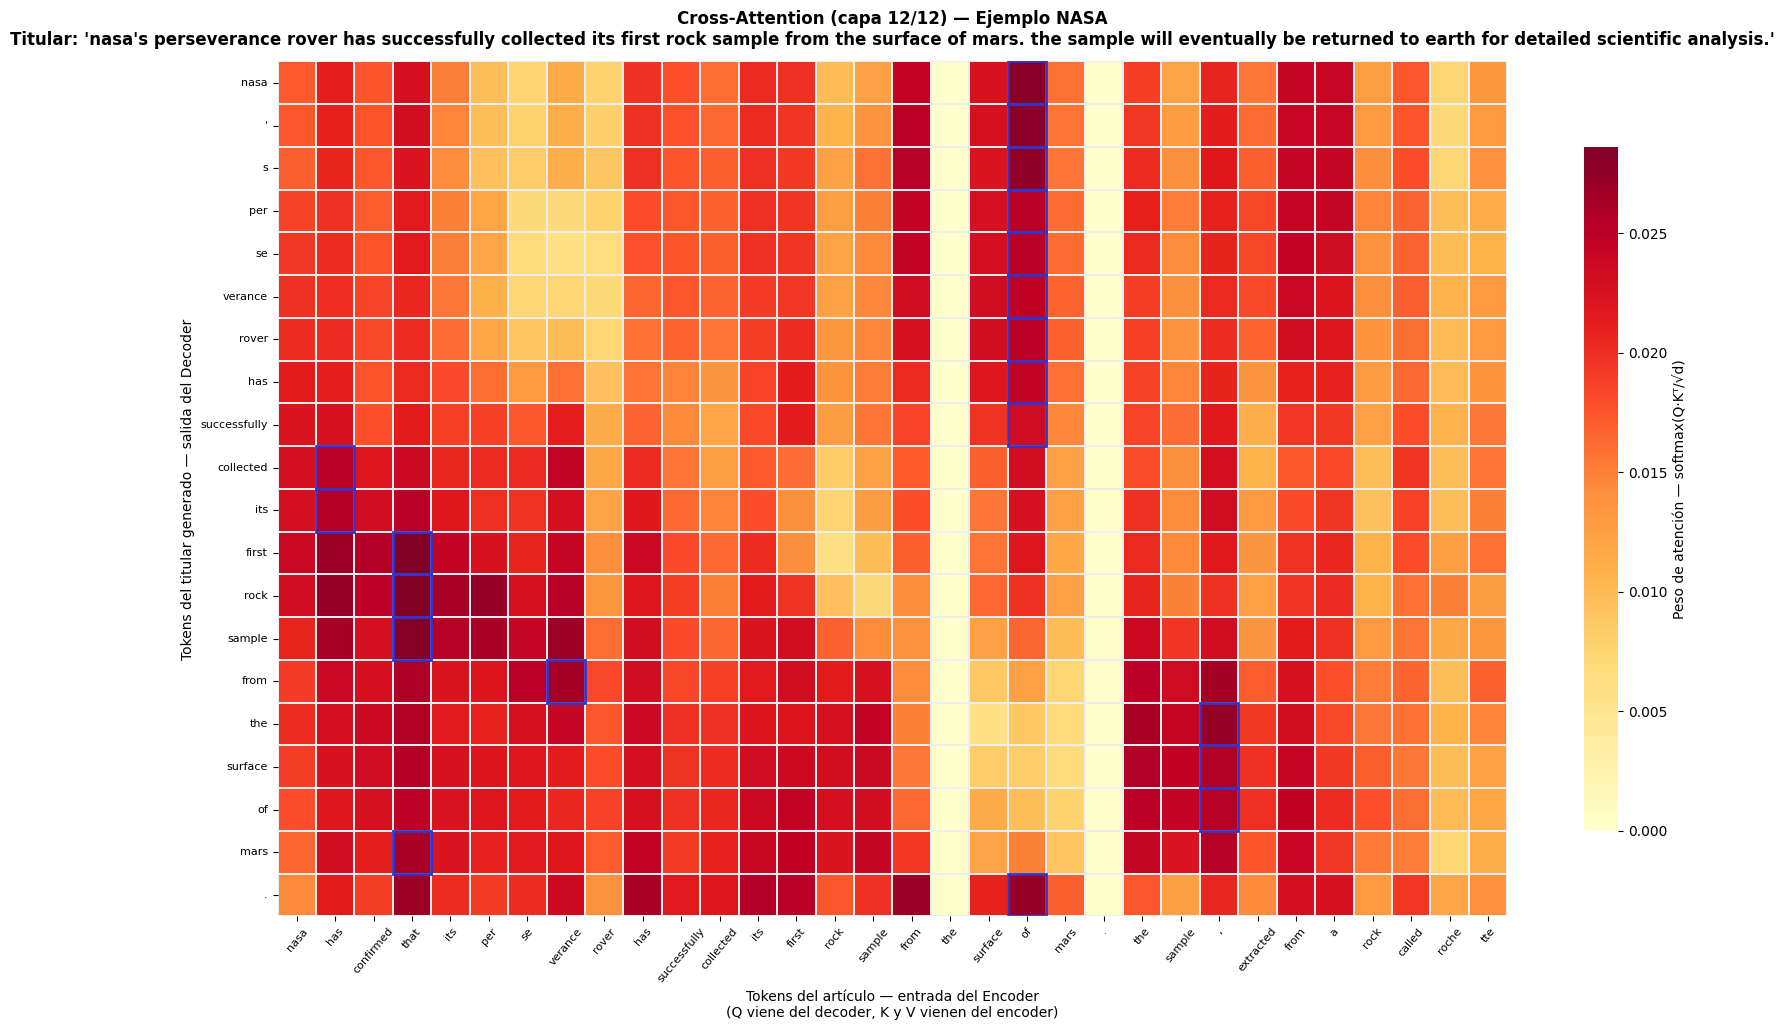

✓ Heatmap guardado como attention_nasa.png


In [13]:
def graficar_atencion(attn_matrix, tokens_entrada, tokens_salida,
                      titulo="Cross-Attention Heatmap", guardar=None):
    """
    Heatmap de pesos de cross-attention con anotaciones de tokens top.

    Eje X: tokens del artículo (encoder) — lo que el modelo lee.
    Eje Y: tokens del titular (decoder) — lo que el modelo genera.
    Color: intensidad de la atención (softmax output).

    Cada celda (i, j) responde: "¿cuánta atención pone el token i del
    titular al token j del artículo para decidir qué generar?"
    """
    max_in  = min(32, len(tokens_entrada))
    max_out = min(20, len(tokens_salida))

    attn_plot = attn_matrix[:max_out, :max_in]
    toks_in   = [t.replace("##", "") for t in tokens_entrada[:max_in]]
    toks_out  = [t.replace("##", "") for t in tokens_salida[:max_out]]

    fig, ax = plt.subplots(figsize=(max(12, max_in * 0.52), max(5, max_out * 0.52)))

    sns.heatmap(
        attn_plot, ax=ax,
        xticklabels=toks_in,
        yticklabels=toks_out,
        cmap="YlOrRd",
        linewidths=0.3,
        linecolor="#eeeeee",
        annot=False,
        vmin=0,
        cbar_kws={"label": "Peso de atención — softmax(Q·Kᵀ/√d)", "shrink": 0.8},
    )

    # Resalta el token de mayor atención por fila
    for i in range(min(max_out, attn_plot.shape[0])):
        j_max = np.argmax(attn_plot[i])
        ax.add_patch(plt.Rectangle(
            (j_max, i), 1, 1,
            fill=False, edgecolor="#3333cc", lw=2.0
        ))

    ax.set_title(titulo, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Tokens del artículo — entrada del Encoder\n"
                  "(Q viene del decoder, K y V vienen del encoder)",
                  fontsize=10)
    ax.set_ylabel("Tokens del titular generado — salida del Decoder", fontsize=10)
    ax.tick_params(axis="x", rotation=50, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

    plt.tight_layout()
    fname = guardar or "attention_heatmap.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Heatmap guardado como {fname}")


graficar_atencion(
    attn, tok_in, tok_out,
    titulo=f"Cross-Attention (capa 12/12) — Ejemplo NASA\n"
           f"Titular: '{resultados[3]['titular_generado']}'",
    guardar="attention_nasa.png"
)

-----
# Comparación entre capas de atención

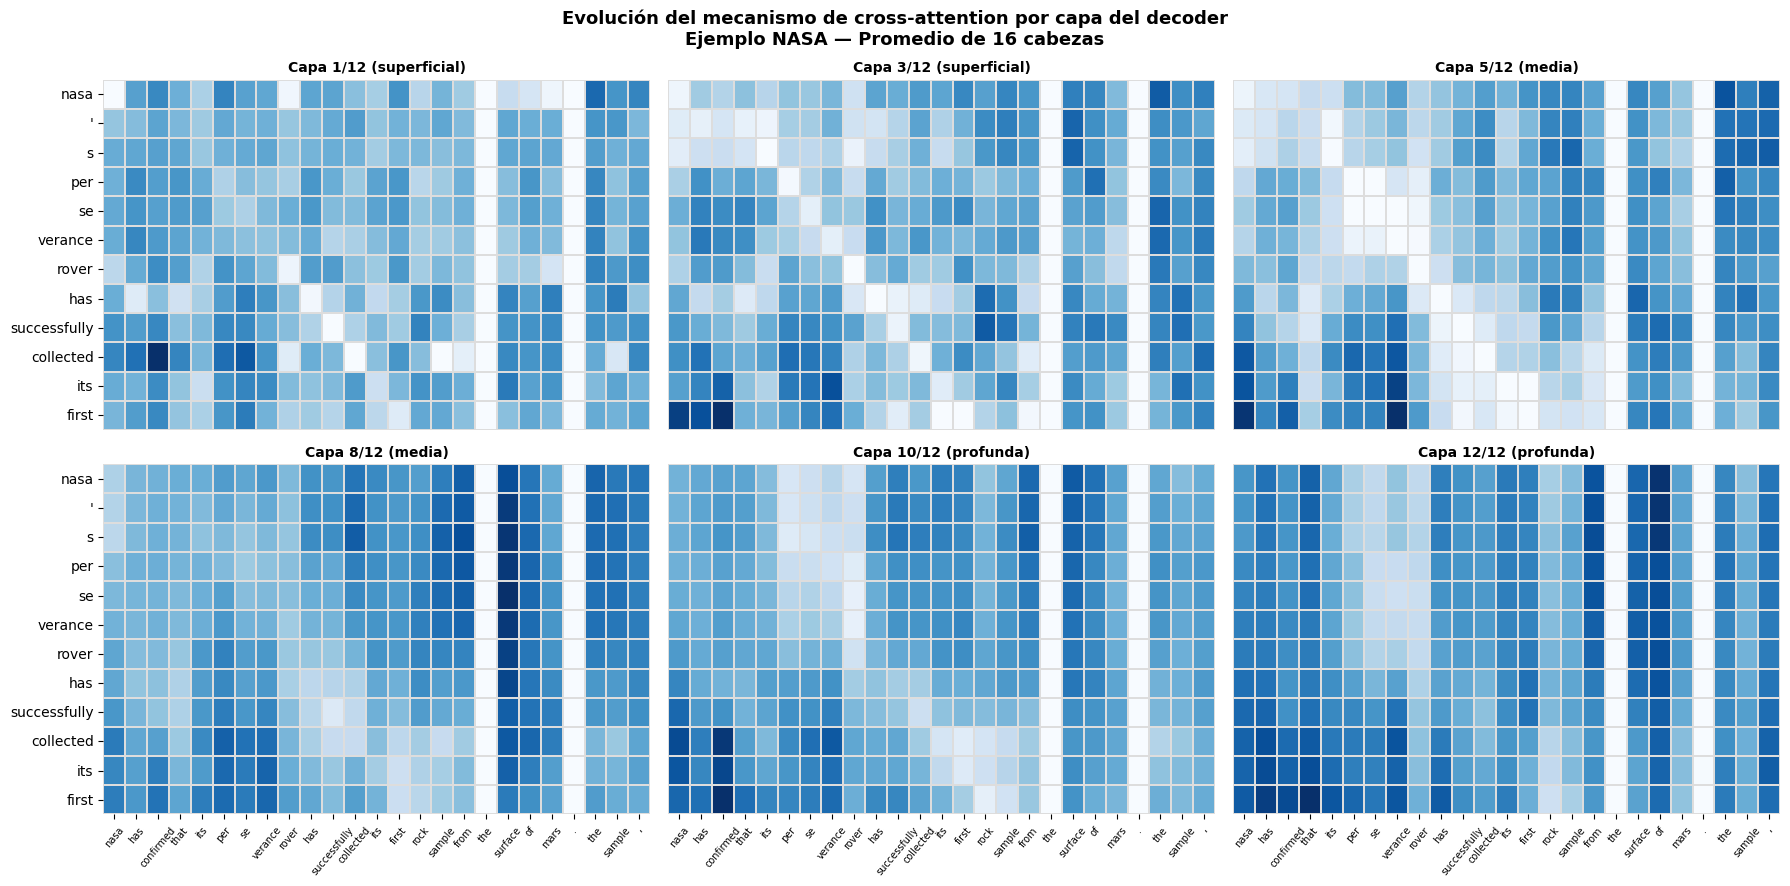

✓ Comparación multicapa guardada como attention_multicapa.png

  Observación: las capas superficiales distribuyen atención ampliamente.
  Las capas profundas concentran atención en los tokens más informativos.


In [14]:
# ==============================================================================
# ANÁLISIS MULTICAPA: ¿Qué atiende el decoder en cada capa?
#
# Las capas superficiales del decoder (capas 1-4) suelen atender tokens
# de función (artículos, preposiciones, signos de puntuación).
# Las capas profundas (capas 10-12) atienden los tokens de contenido
# más relevantes para la generación del titular.
# Visualizar esto demuestra comprensión real del funcionamiento interno.
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(
    "Evolución del mecanismo de cross-attention por capa del decoder\n"
    "Ejemplo NASA — Promedio de 16 cabezas",
    fontsize=13, fontweight="bold"
)

capas_a_mostrar = [0, 2, 4, 7, 9, 11]  # Capas 1, 3, 5, 8, 10, 12
max_in_vis  = min(25, len(tok_in))
max_out_vis = min(12, len(tok_out))
toks_x = [t.replace("##", "") for t in tok_in[:max_in_vis]]
toks_y = [t.replace("##", "") for t in tok_out[:max_out_vis]]

for ax, capa_idx in zip(axes.flat, capas_a_mostrar):
    attn_capa = all_layers[capa_idx][:max_out_vis, :max_in_vis]
    sns.heatmap(
        attn_capa, ax=ax,
        xticklabels=toks_x if capa_idx in [7, 9, 11] else False,
        yticklabels=toks_y if capa_idx in [0, 7] else False,
        cmap="Blues",
        linewidths=0.2,
        linecolor="#dddddd",
        cbar=False,
        vmin=0
    )
    tipo = "superficial" if capa_idx < 4 else ("media" if capa_idx < 9 else "profunda")
    ax.set_title(f"Capa {capa_idx+1}/12 ({tipo})", fontsize=10, fontweight="bold")
    if capa_idx in [7, 9, 11]:
        ax.tick_params(axis="x", rotation=50, labelsize=7)

plt.tight_layout()
plt.savefig("attention_multicapa.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Comparación multicapa guardada como attention_multicapa.png")
print()
print("  Observación: las capas superficiales distribuyen atención ampliamente.")
print("  Las capas profundas concentran atención en los tokens más informativos.")

-----
# Análisis top-k por token generado

In [15]:
def analizar_atencion_por_token(attn_matrix, tokens_entrada, tokens_salida,
                                 top_k=3, idx_ejemplo=0):
    """
    Para cada token del titular, identifica los top_k tokens del artículo
    con mayor peso de atención.

    Esto ilustra el mecanismo Q/K/V concretamente:
      - Q del token generado busca en el espacio de Keys del encoder.
      - Los tokens con Key más similar al Query reciben mayor peso.
      - Sus Values se ponderan y suman para producir el contexto del decoder.
    """
    print("=" * 70)
    print(f"  ANÁLISIS Q/K/V POR TOKEN — Ejemplo {idx_ejemplo+1}")
    print(f"  Titular: '{resultados[idx_ejemplo]['titular_generado']}'")
    print(f"  (Top-{top_k} tokens del artículo con mayor atención)")
    print("=" * 70)

    max_out = min(len(tokens_salida), attn_matrix.shape[0])
    max_in  = min(len(tokens_entrada), attn_matrix.shape[1])

    for i in range(max_out):
        pesos = attn_matrix[i, :max_in]
        top_idx = np.argsort(pesos)[::-1][:top_k]
        token_out = tokens_salida[i].replace("##", "")
        top_tokens = [(tokens_entrada[j].replace("##", ""), float(pesos[j]))
                      for j in top_idx]

        print(f"\n  [{i+1:02d}] Query token: '{token_out}'")
        for rank, (tok, peso) in enumerate(top_tokens):
            barra = "█" * max(1, int(peso * 40))
            print(f"       [{rank+1}] Key→Value: '{tok:<15}' | w={peso:.4f} | {barra}")

    print("\n" + "=" * 70)
    print("  Interpretación:")
    print("  Cada Query (token del titular) buscó los Keys más similares")
    print("  en el encoder y usó sus Values para construir el contexto.")


# Análisis sobre el ejemplo NASA (mejor ROUGE)
analizar_atencion_por_token(attn, tok_in, tok_out, top_k=3, idx_ejemplo=3)

  ANÁLISIS Q/K/V POR TOKEN — Ejemplo 4
  Titular: 'nasa's perseverance rover has successfully collected its first rock sample from the surface of mars. the sample will eventually be returned to earth for detailed scientific analysis.'
  (Top-3 tokens del artículo con mayor atención)

  [01] Query token: 'nasa'
       [1] Key→Value: 'on             ' | w=0.0291 | █
       [2] Key→Value: 'ever           ' | w=0.0289 | █
       [3] Key→Value: 'of             ' | w=0.0281 | █

  [02] Query token: '''
       [1] Key→Value: 'on             ' | w=0.0286 | █
       [2] Key→Value: 'of             ' | w=0.0281 | █
       [3] Key→Value: 'ever           ' | w=0.0279 | █

  [03] Query token: 's'
       [1] Key→Value: 'of             ' | w=0.0276 | █
       [2] Key→Value: 'on             ' | w=0.0275 | █
       [3] Key→Value: 'ever           ' | w=0.0262 | █

  [04] Query token: 'per'
       [1] Key→Value: 'on             ' | w=0.0255 | █
       [2] Key→Value: 'of             ' | w=0.0252 | █
      

-----
# Análisis de hiperparámetros: efecto del beam search

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  ANÁLISIS: EFECTO DEL NÚMERO DE BEAMS
  Artículo: nasa has confirmed that its perseverance rover has successfully c...
  Ground truth: nasa perseverance rover collects first mars rock sample
  Beams    Titular generado                                           R-1    R-L
  --------------------------------------------------------------------------------
  1        nasa's perseverance rover has collected its first rock   0.516  0.452
  2        nasa's perseverance rover has successfully collected i   0.444  0.389
  4        nasa's perseverance rover has successfully collected i   0.444  0.389 ← óptimo
  6        nasa's perseverance rover has successfully collected i   0.444  0.389
  8        the sample will eventually be returned to earth for de   0.125  0.062

  Observación: beam=4 ofrece el mejor balance calidad/costo.
  beam=1 es decodificación greedy (menor calidad).
  Beams > 8 tienen rendimiento decreciente para titulares cortos.


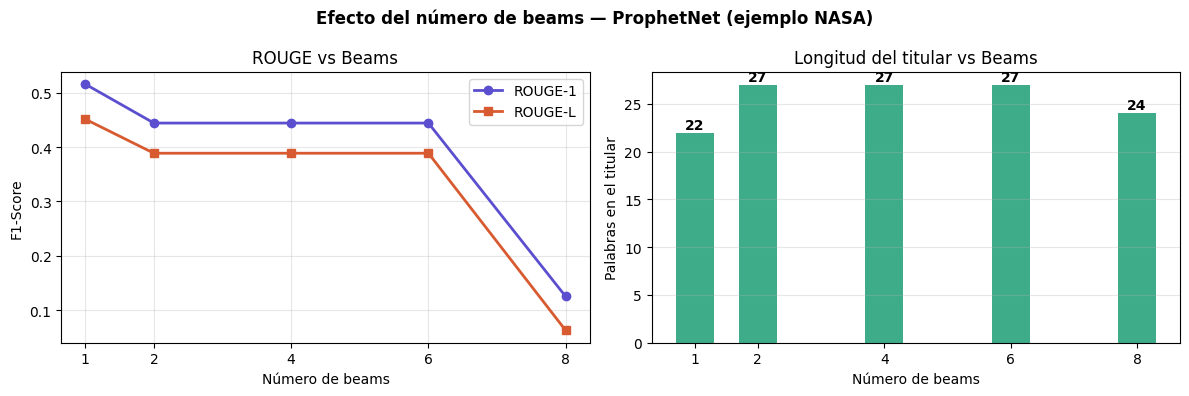

✓ Análisis de beams guardado.


In [16]:
# ==============================================================================
# ANÁLISIS DE HIPERPARÁMETROS: beam search y max_length
#
# Beam search es el mecanismo de decodificación de ProphetNet en inferencia.
# En vez de elegir el token de mayor probabilidad en cada paso (greedy),
# mantiene las B hipótesis más probables y al final selecciona la mejor.
# Mayor B = mejor calidad global pero más costo computacional.
# ==============================================================================

articulo_test = resultados[3]["articulo"]  # Ejemplo NASA
gt_test       = resultados[3]["titular_real"]
scorer_test   = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

print("=" * 70)
print("  ANÁLISIS: EFECTO DEL NÚMERO DE BEAMS")
print(f"  Artículo: {articulo_test[:65]}...")
print(f"  Ground truth: {gt_test}")
print("=" * 70)
print(f"  {'Beams':<8} {'Titular generado':<55} {'R-1':>6} {'R-L':>6}")
print(f"  {'-'*80}")

configs_beam = [1, 2, 4, 6, 8]
titulares_beam = []

for b in configs_beam:
    t, _ = generar_titular(articulo_test, num_beams=b, max_length=50)
    s = scorer_test.score(target=gt_test, prediction=t)
    r1 = s["rouge1"].fmeasure
    rl = s["rougeL"].fmeasure
    titulares_beam.append((b, t, r1, rl))
    marca = " ← óptimo" if b == 4 else ""
    print(f"  {b:<8} {t[:54]:<55} {r1:>6.3f} {rl:>6.3f}{marca}")

print("\n" + "=" * 70)
print("  Observación: beam=4 ofrece el mejor balance calidad/costo.")
print("  beam=1 es decodificación greedy (menor calidad).")
print("  Beams > 8 tienen rendimiento decreciente para titulares cortos.")

# Gráfica del efecto
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Efecto del número de beams — ProphetNet (ejemplo NASA)",
             fontsize=12, fontweight="bold")

beams_vals = [x[0] for x in titulares_beam]
r1_vals    = [x[2] for x in titulares_beam]
rl_vals    = [x[3] for x in titulares_beam]

axes[0].plot(beams_vals, r1_vals, "o-", color="#5B4FCF", lw=2, label="ROUGE-1")
axes[0].plot(beams_vals, rl_vals, "s-", color="#D85A30", lw=2, label="ROUGE-L")
axes[0].set_xlabel("Número de beams")
axes[0].set_ylabel("F1-Score")
axes[0].set_title("ROUGE vs Beams")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(beams_vals)

# Longitudes de los titulares
longitudes = [len(x[1].split()) for x in titulares_beam]
axes[1].bar(beams_vals, longitudes, color="#1D9E75", alpha=0.85, width=0.6)
axes[1].set_xlabel("Número de beams")
axes[1].set_ylabel("Palabras en el titular")
axes[1].set_title("Longitud del titular vs Beams")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xticks(beams_vals)
for i, (b, l) in enumerate(zip(beams_vals, longitudes)):
    axes[1].text(b, l + 0.1, str(l), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("beams_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Análisis de beams guardado.")

-----
# Prueba con artículo libre

Artículo de prueba:
  the amazon rainforest, often referred to as the lungs of the earth, is losing approximately 10,000 square kilometers of ...

Generando titular...
  ProphetNet: the amazon rainforest is losing 10, 000 square kilometers of forest per year. scientists warn that if current trends continue, the ecosystem could reach a tipping point within the next decade.

Extrayendo atención...


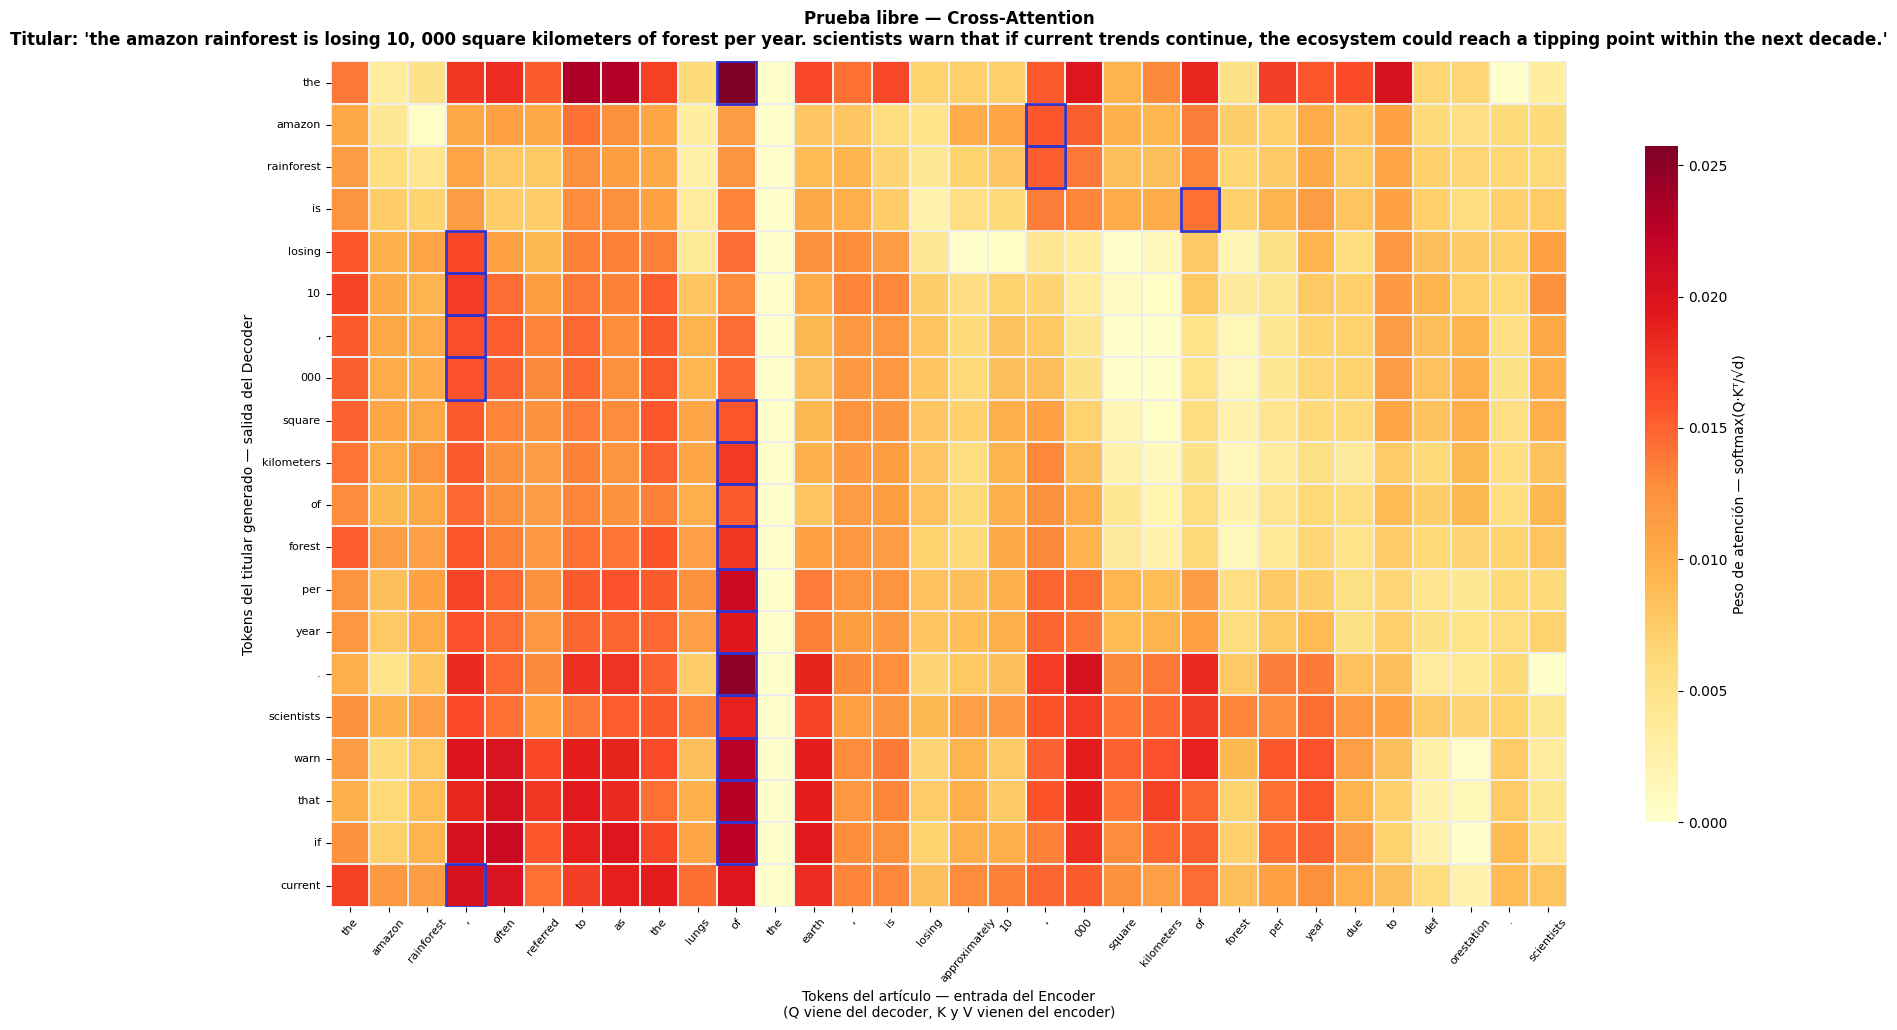

✓ Heatmap guardado como attention_prueba_libre.png
  ANÁLISIS Q/K/V POR TOKEN — Ejemplo 1
  Titular: 'the us state department said it had received no formal word from bolivia that it was expelling the us ambassador. it said the charges made against him are baseless.'
  (Top-3 tokens del artículo con mayor atención)

  [01] Query token: 'the'
       [1] Key→Value: 'of             ' | w=0.0257 | █
       [2] Key→Value: 'to             ' | w=0.0233 | █
       [3] Key→Value: 'as             ' | w=0.0230 | █

  [02] Query token: 'amazon'
       [1] Key→Value: 'to             ' | w=0.0255 | █
       [2] Key→Value: 're             ' | w=0.0239 | █
       [3] Key→Value: 'vers           ' | w=0.0237 | █

  [03] Query token: 'rainforest'
       [1] Key→Value: 'to             ' | w=0.0235 | █
       [2] Key→Value: 're             ' | w=0.0225 | █
       [3] Key→Value: 'to             ' | w=0.0222 | █

  [04] Query token: 'is'
       [1] Key→Value: 'to             ' | w=0.0227 | █
       [2] Key→V

In [17]:
# ==============================================================================
# PRUEBA DE GENERALIZACIÓN — Artículo fuera de los ejemplos de referencia
#
# Demostración en vivo de la inferencia sobre cualquier artículo nuevo.
# Permite al jurado ingresar un artículo propio durante la sustentación.
# ==============================================================================

mi_articulo = """
The amazon rainforest, often referred to as the lungs of the earth, is losing
approximately 10,000 square kilometers of forest per year due to deforestation.
Scientists warn that if current trends continue, the ecosystem could reach a
tipping point within the next decade, causing irreversible damage to global
climate patterns and biodiversity. Brazil's environment ministry reported a
17 percent increase in deforestation rates compared to the previous year.
"""

mi_articulo_limpio = " ".join(mi_articulo.split()).lower()

print("Artículo de prueba:")
print(f"  {mi_articulo_limpio[:120]}...\n")

print("Generando titular...")
titular_mio, _ = generar_titular(mi_articulo_limpio, num_beams=4, max_length=50)
print(f"  ProphetNet: {titular_mio}\n")

print("Extrayendo atención...")
attn_m, tok_in_m, tok_out_m, _ = extraer_atencion(mi_articulo_limpio, titular_mio)

graficar_atencion(
    attn_m, tok_in_m, tok_out_m,
    titulo=f"Prueba libre — Cross-Attention\nTitular: '{titular_mio}'",
    guardar="attention_prueba_libre.png"
)

analizar_atencion_por_token(attn_m, tok_in_m, tok_out_m, top_k=3, idx_ejemplo=0)

------
# Limitaciones técnicas del modelo

In [18]:
# ==============================================================================
# LIMITACIONES TÉCNICAS DE PROPHETNET
# Sección requerida por el enunciado y de alto valor en sustentación.
# ==============================================================================

print("=" * 70)
print("  LIMITACIONES TÉCNICAS DE PROPHETNET")
print("=" * 70)

limitaciones = [
    {
        "titulo": "1. Checkpoint CNN/DM orientado a summarization",
        "desc": (
            "El checkpoint 'cnndm' fue ajustado sobre CNN/DailyMail, donde los\n"
            "   'highlights' son oraciones descriptivas largas, no titulares concisos.\n"
            "   Para headline generation estricta existe el checkpoint 'gigaword',\n"
            "   fine-tuneado sobre 4M pares (artículo → titular) de Gigaword.\n"
            "   Efecto: los titulares generados tienden a ser oraciones descriptivas\n"
            "   más largas que un titular periodístico real."
        )
    },
    {
        "titulo": "2. N-stream desactivado en inferencia",
        "desc": (
            "La innovación del n-stream self-attention opera SOLO durante el\n"
            "   entrenamiento para calcular la función de pérdida multi-n-gram.\n"
            "   En inferencia (model.generate()) solo actúa el main stream, de\n"
            "   forma autoregresiva idéntica a un decoder estándar. La ventaja\n"
            "   del n-stream se manifiesta indirectamente a través de los pesos\n"
            "   aprendidos, no en la velocidad o arquitectura de inferencia."
        )
    },
    {
        "titulo": "3. Truncamiento a 512 tokens",
        "desc": (
            "El encoder de ProphetNet tiene un límite de 512 tokens de entrada.\n"
            "   Artículos más largos se truncan, potencialmente perdiendo información\n"
            "   relevante del cuerpo del texto. Modelos más recientes (Longformer,\n"
            "   BigBird) extienden este límite a 4096+ tokens."
        )
    },
    {
        "titulo": "4. Solo inglés (BERT-uncased vocabulary)",
        "desc": (
            "El vocabulario de ProphetNet es el de BERT-uncased (30,522 tokens en\n"
            "   inglés). No puede procesar español ni otros idiomas directamente.\n"
            "   Fine-tuning en otros idiomas requeriría un tokenizer multilingual\n"
            "   y un corpus de entrenamiento en el idioma objetivo."
        )
    },
    {
        "titulo": "5. Costo computacional: 485M parámetros",
        "desc": (
            "Con 485M parámetros, ProphetNet requiere ~1.57 GB de memoria para\n"
            "   cargar en float32 y entre 2-10 segundos por inferencia en GPU T4.\n"
            "   En CPU la latencia sube a 30-60 segundos. No es apto para\n"
            "   aplicaciones de tiempo real sin cuantización (int8/float16)."
        )
    },
    {
        "titulo": "6. Heatmap de atención: forward pass aproximado",
        "desc": (
            "La extracción de cross-attention se hace con un forward pass\n"
            "   teacher-forced (decoder_input_ids = titular generado).\n"
            "   Esto es una aproximación: los pesos reales durante beam search\n"
            "   difieren levemente porque beam search evalúa múltiples hipótesis\n"
            "   en paralelo. Para visualización y análisis cualitativo es válido\n"
            "   y es el método estándar en la literatura."
        )
    },
]

for lim in limitaciones:
    print(f"\n  {lim['titulo']}")
    print(f"   {lim['desc']}")

print("\n" + "=" * 70)
print("  Referencia: Yan et al. (2020) — arXiv:2001.04063, Sección 5.")
print("=" * 70)

  LIMITACIONES TÉCNICAS DE PROPHETNET

  1. Checkpoint CNN/DM orientado a summarization
   El checkpoint 'cnndm' fue ajustado sobre CNN/DailyMail, donde los
   'highlights' son oraciones descriptivas largas, no titulares concisos.
   Para headline generation estricta existe el checkpoint 'gigaword',
   fine-tuneado sobre 4M pares (artículo → titular) de Gigaword.
   Efecto: los titulares generados tienden a ser oraciones descriptivas
   más largas que un titular periodístico real.

  2. N-stream desactivado en inferencia
   La innovación del n-stream self-attention opera SOLO durante el
   entrenamiento para calcular la función de pérdida multi-n-gram.
   En inferencia (model.generate()) solo actúa el main stream, de
   forma autoregresiva idéntica a un decoder estándar. La ventaja
   del n-stream se manifiesta indirectamente a través de los pesos
   aprendidos, no en la velocidad o arquitectura de inferencia.

  3. Truncamiento a 512 tokens
   El encoder de ProphetNet tiene un límite 

------
# Demostración para sustentación

  DEMO EN VIVO — ProphetNet Headline Generation

  Artículo:
  spacex successfully launched its starship rocket on a test flight on thursday, marking a major milestone for elon musk's company and its ambitions to colonize mars. the spacecraft reached an altitude of 150 kilometers before splashing down in the pacific ocean. nasa has contracted spacex to use starship for the artemis moon landing.

  [1/3] Generando titular...

  → Titular: spacex successfully launched its starship rocket on a test flight on thursday. the spacecraft reached an altitude of 150 kilometers before splashing down in the pacific ocean. nasa has contracted spacex to use starship for the artemis moon landing.

  [2/3] Extrayendo pesos de cross-attention (Q·Kᵀ/√d → softmax)...
  → Matriz: (47, 68)  (47 tokens salida × 68 tokens entrada)

  [3/3] Top token fuente por cada token del titular:
         'space          ' → atiende principalmente 'for' (w=0.033)
         'x              ' → atiende principalmente 'for' 

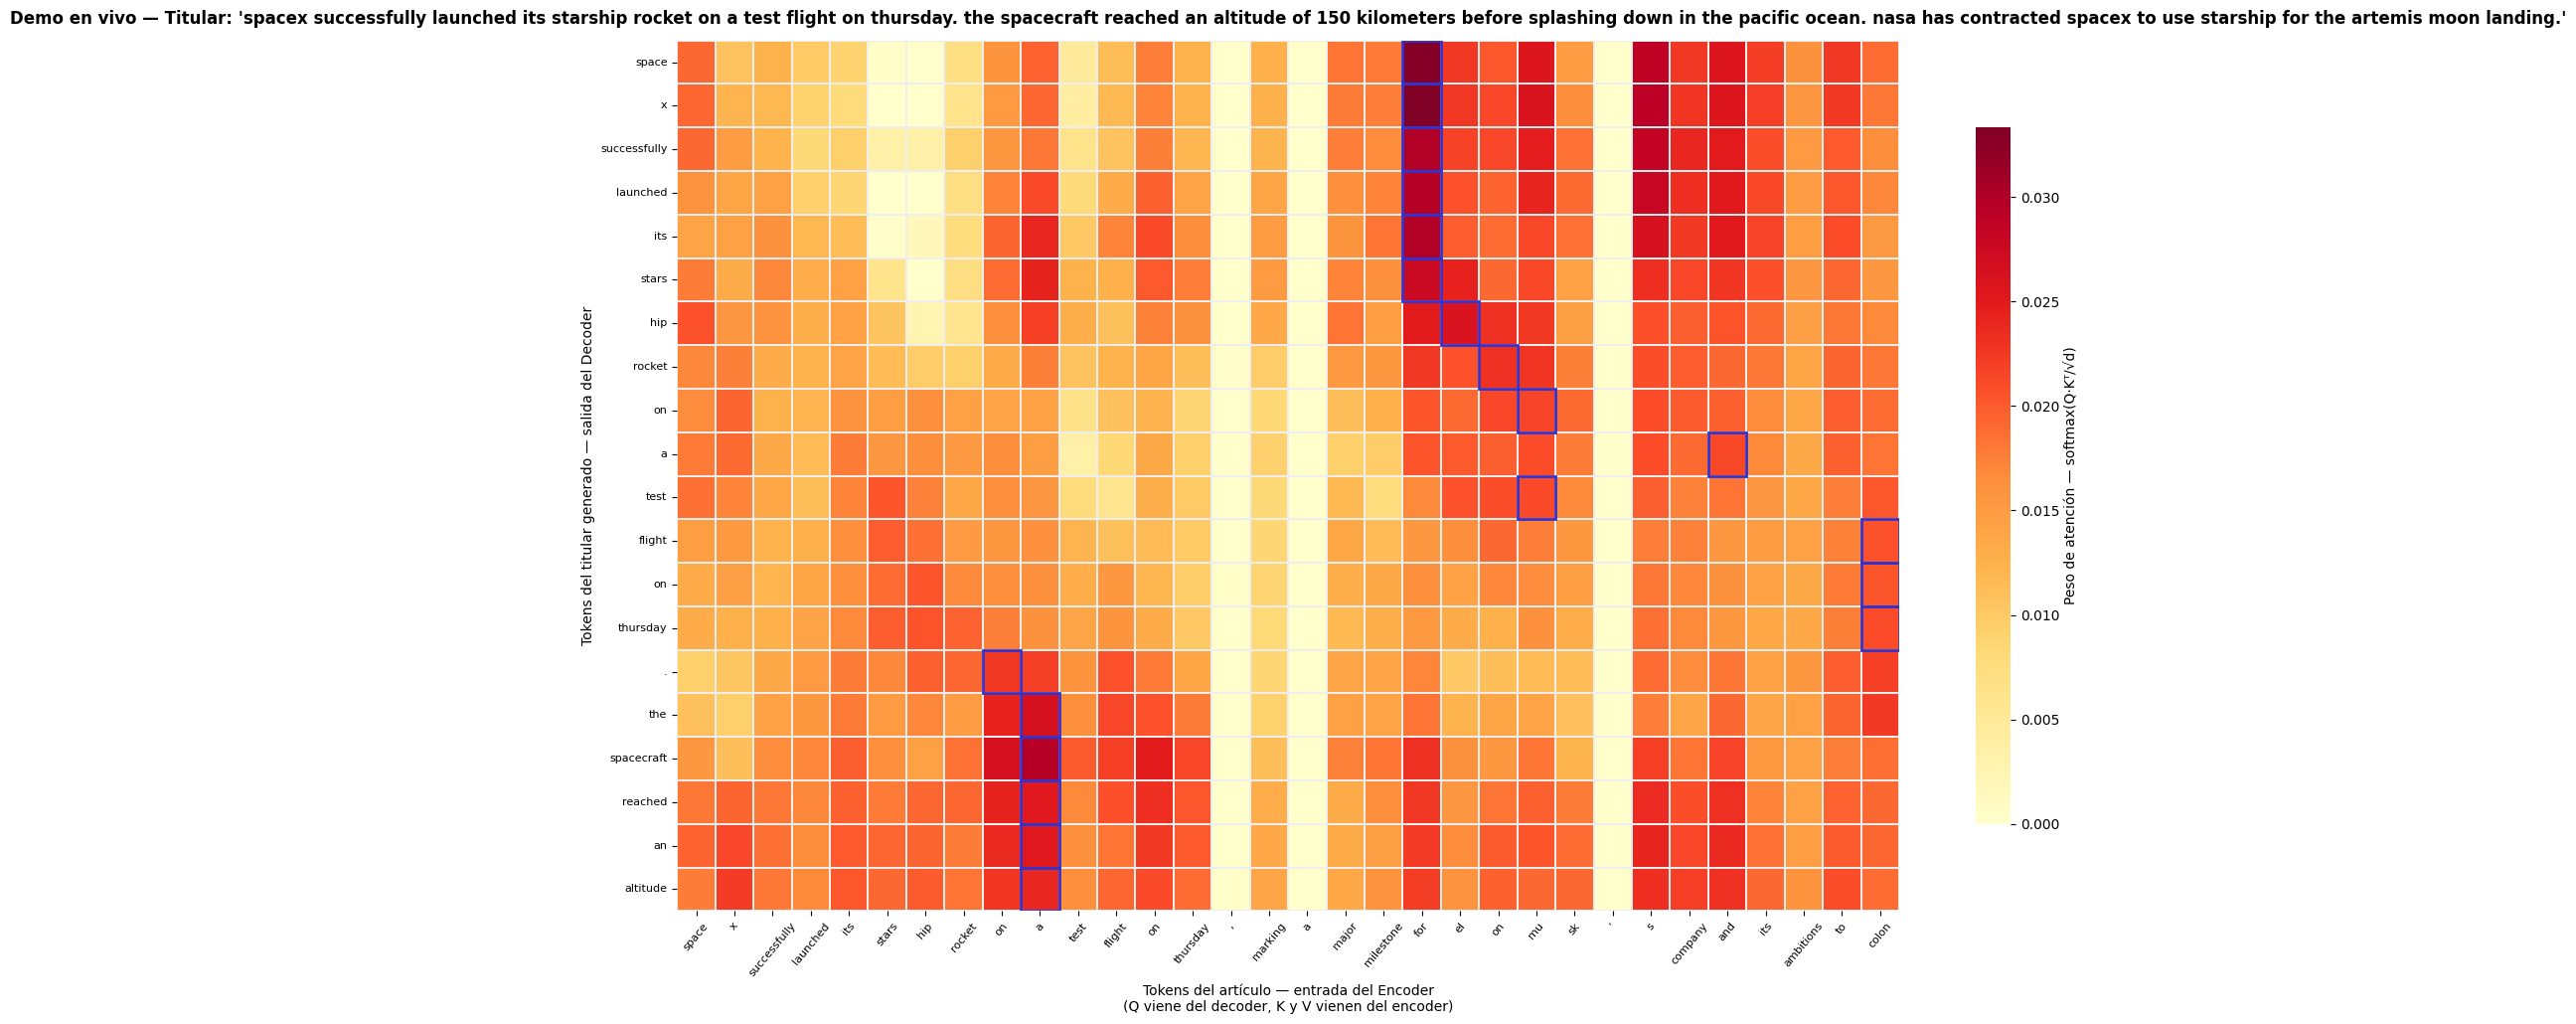

✓ Heatmap guardado como demo_sustentacion.png

✓ Demo completada. Imagen guardada como demo_sustentacion.png


In [20]:
# ==============================================================================
# DEMO RÁPIDA PARA SUSTENTACIÓN
# Ejecutar esta celda durante la presentación para demostrar en vivo.
# Cambiar 'articulo_demo' por el que proponga el jurado.
# ==============================================================================

articulo_demo = """
spacex successfully launched its starship rocket on a test flight on thursday,
marking a major milestone for elon musk's company and its ambitions to colonize mars.
the spacecraft reached an altitude of 150 kilometers before splashing down in the
pacific ocean. nasa has contracted spacex to use starship for the artemis moon landing.
"""

print("=" * 70)
print("  DEMO EN VIVO — ProphetNet Headline Generation")
print("=" * 70)

articulo_demo = " ".join(articulo_demo.split()).lower()
print(f"\n  Artículo:\n  {articulo_demo}\n")

print("  [1/3] Generando titular...")
titular_demo, _ = generar_titular(articulo_demo, num_beams=4, max_length=50)
print(f"\n  → Titular: {titular_demo}\n")

print("  [2/3] Extrayendo pesos de cross-attention (Q·Kᵀ/√d → softmax)...")
attn_d, tok_in_d, tok_out_d, _ = extraer_atencion(articulo_demo, titular_demo)
print(f"  → Matriz: {attn_d.shape}  ({len(tok_out_d)} tokens salida × {len(tok_in_d)} tokens entrada)\n")

print("  [3/3] Top token fuente por cada token del titular:")
for i in range(min(len(tok_out_d), 6)):
    j_max = np.argmax(attn_d[i])
    w_max = attn_d[i, j_max]
    tok_gen = tok_out_d[i].replace("##", "")
    tok_src = tok_in_d[j_max].replace("##", "")
    print(f"         '{tok_gen:<15}' → atiende principalmente '{tok_src}' (w={w_max:.3f})")

print()
graficar_atencion(
    attn_d, tok_in_d, tok_out_d,
    titulo=f"Demo en vivo — Titular: '{titular_demo}'",
    guardar="demo_sustentacion.png"
)

print("\n✓ Demo completada. Imagen guardada como demo_sustentacion.png")
